<a href="https://colab.research.google.com/github/Jenycantik/Kalkulator_/blob/main/presensi_wajah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mtcnn
!pip install deepface


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.0/297.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstall

In [ ]:
from matplotlib import pyplot as plt
import cv2
from PIL import Image
import numpy as np

import mtcnn
from mtcnn.mtcnn import MTCNN
from matplotlib.patches import Rectangle

from os import listdir
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
DIRECTORY = "/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0"
DIRECTORY_train='/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train'
DIRECTORY_test='/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Sistem_Presensi_Wajah_V2.0 Data_Test'

(4640, 3488, 3)


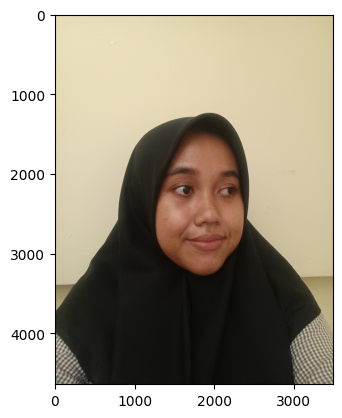

In [ ]:
filename = "/content/drive/MyDrive/5231911016_Ameliawati_06.jpg"
pixels = plt.imread(filename)

print(pixels.shape)   # Biasanya (height, width, 3)
plt.imshow(pixels)
plt.show()


MTCNN


In [ ]:
!pip install lz4>=4.3.3


In [ ]:
detector = MTCNN()

results = detector.detect_faces(pixels)
results

[{'box': [1244, 1586, 1130, 1589],
  'confidence': np.float64(0.9993798732757568),
  'keypoints': {'nose': [np.int64(1953), np.int64(2548)],
   'mouth_right': [np.int64(2127), np.int64(2802)],
   'right_eye': [np.int64(2173), np.int64(2225)],
   'left_eye': [np.int64(1626), np.int64(2206)],
   'mouth_left': [np.int64(1624), np.int64(2807)]}}]

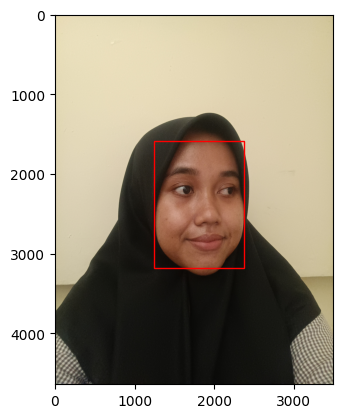

In [ ]:
def draw_image_with_boxes(data, result_list):
    plt.imshow(data)
    ax = plt.gca()
    for result in result_list:
        x, y, width, height = result['box']
        rect = Rectangle((x, y), width, height, fill=False, color='red')
        ax.add_patch(rect)
    plt.show()

draw_image_with_boxes(pixels, results)

Extract and normalise the face pixels

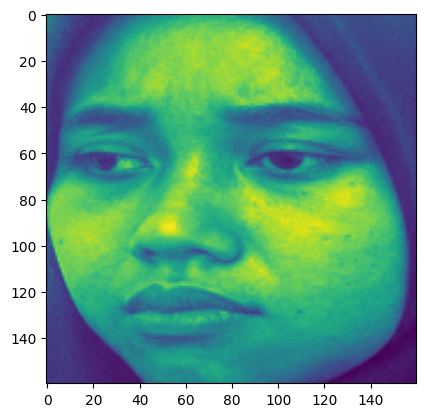

In [ ]:
def extract_face_from_file(filename, required_size=(160, 160)):
    image = Image.open(filename)

    return extract_face(image, required_size)

def extract_face(image, required_size=(160, 160)):
    image = image.convert('RGB')
    pixels = np.asarray(image)
    results = detector.detect_faces(pixels)

    x1, y1, width, height = results[0]['box']

    x1, y1 = abs(x1), abs(y1)
    x2, y2 = x1 + width, y1 + height

    face = pixels[y1:y2, x1:x2]

    image = Image.fromarray(face)
    image = image.resize(required_size)
    face_array = np.asarray(image)
    gray_face = cv2.cvtColor(face_array, cv2.COLOR_BGR2GRAY)

    return gray_face

detector = MTCNN()

face_pixels = extract_face_from_file("/content/drive/MyDrive/5231911016_Ameliawati_11.jpg")

plt.imshow(face_pixels)

Data set test and train


In [ ]:
import os

def list_files(directory, contains=".jpg"):
    files = []
    for root, dirs, filenames in os.walk(directory):
        for f in filenames:
            if contains.lower() in f.lower():
                # Simpan path relatif supaya bisa digabung dengan directory nanti
                files.append(os.path.relpath(os.path.join(root, f), directory))
    return files


Ditemukan 1268 file gambar.


Menampilkan gambar: 100%|██████████| 16/16 [00:53<00:00,  3.32s/it]


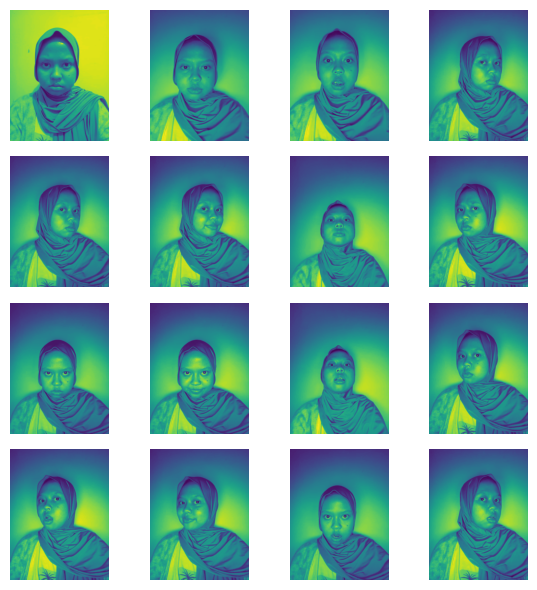

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# path dataset kamu
DIRECTORY_train = "/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train"

# cari semua file gambar (termasuk subfolder)
files = []
for root, dirs, filenames in os.walk(DIRECTORY_train):
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            files.append(os.path.join(root, filename))

print(f"Ditemukan {len(files)} file gambar.")

# tampilkan seperti contoh (warna biru–hijau–kuning)
if len(files) == 0:
    print("⚠️ Tidak ada file ditemukan.")
else:
    plt.figure(figsize=(6, 6))
    for i, path in enumerate(tqdm(files[:16], desc="Menampilkan gambar")):
        # baca sebagai grayscale
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        plt.subplot(4, 4, i + 1)
        plt.axis('off')
        plt.imshow(img)  # default: colormap viridis
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import pandas as pd

# Path folder dataset
DATA_TRAIN = "/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train"

# List semua file
files = os.listdir(DATA_TRAIN)

# Simpan ke list
data = []

for file in files:
    if "_" in file:
        parts = file.split("_")
        subject = parts[0]              # ambil NIM
        category = parts[1]             # ambil nama orang
        data.append([subject, category, file])

# Bikin dataframe
df_train = pd.DataFrame(data, columns=["subject", "category", "filename"])
# Add a 'label' column using the 'category' for consistency
df_train['label'] = df_train['category']
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("=== DATA TRAIN ===")
print(df.to_string())


=== DATA TRAIN ===
         subject                       category                                         filename                          label
0     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_21.jpg                   ULFAH NAFIAH
1     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_23.jpg                   ULFAH NAFIAH
2     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_24.jpg                   ULFAH NAFIAH
3     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_27.jpg                   ULFAH NAFIAH
4     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_25.jpg                   ULFAH NAFIAH
5     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_26.jpg                   ULFAH NAFIAH
6     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NA

In [ ]:
import os
import pandas as pd

# Path folder data test
DATA_TEST = "/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train"
# List semua file di folder test
files = os.listdir(DATA_TEST)

# Simpan ke list
data_test = []

for file in files:
    if "_" in file:
        parts = file.split("_")
        subject = parts[0]              # ambil NIM
        category = parts[1]             # ambil nama orang
        data_test.append([subject, category, file])

# Bikin dataframe
df_test = pd.DataFrame(data_test, columns=["subject", "category", "filename"])
df_test['label'] = df_test['category']
# === BIAR SEMUA KELIATAN TANPA POTONG ===
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# === TAMPILKAN HASILNYA ===
print("\n===== DATA TEST =====")
print(df_test.to_string())



===== DATA TEST =====
         subject                       category                                         filename                          label
0     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_21.jpg                   ULFAH NAFIAH
1     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_23.jpg                   ULFAH NAFIAH
2     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_24.jpg                   ULFAH NAFIAH
3     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_27.jpg                   ULFAH NAFIAH
4     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_25.jpg                   ULFAH NAFIAH
5     5231811026                   ULFAH NAFIAH                   5231811026_ULFAH NAFIAH_26.jpg                   ULFAH NAFIAH
6     5231811026                   ULFAH NAFIAH                   5231811026_ULFA

In [ ]:
label_counts = df['label'].value_counts()
df_filtered = df[df['label'].isin(label_counts[label_counts > 1].index)]

df_train, df_test = train_test_split(
    df_filtered, test_size=0.2, stratify=df_filtered['label'], random_state=42
)


In [ ]:
# Hitung jumlah foto per label
label_counts = df['label'].value_counts()

# Hapus label yang hanya punya 1 foto
df_filtered = df[df['label'].isin(label_counts[label_counts > 1].index)]

print("Jumlah data sebelum filter:", len(df))
print("Jumlah data setelah filter :", len(df_filtered))
print("Jumlah label unik:", df_filtered['label'].nunique())

# Sekarang baru aman untuk stratify
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(
    df_filtered,
    test_size=0.2,
    stratify=df_filtered['label'],
    random_state=42
)

print("Jumlah data train:", len(df_train))
print("Jumlah data test :", len(df_test))


Jumlah data sebelum filter: 1268
Jumlah data setelah filter : 1243
Jumlah label unik: 53
Jumlah data train: 994
Jumlah data test : 249


In [ ]:
# Ambil label dari dataframe train / test
y_train = df_train['label']
y_test  = df_test['label']

# Ubah ke numpy array
y_train = y_train.to_numpy()
y_test  = y_test.to_numpy()


In [ ]:
y_train = y_train.tolist()
y_test = y_test.tolist()

In [ ]:
detector = MTCNN()

def load_dataset2(dataset):
    faces = list()
    for filename in tqdm(dataset["filename"]):
        path = DIRECTORY_test + filename
        # get face
        face = extract_face_from_file(path)
        faces.append(face)
    return np.asarray(faces)

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# direktori data
DIRECTORY_train = '/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train'
DIRECTORY_test = '/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Sistem_Presensi_Wajah_V2.0 Data_Test'

# fungsi untuk load dataset (train/test)
def load_dataset(dataset_dir, size=(160,160)):
    faces = []
    for filename in tqdm(os.listdir(dataset_dir)):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(dataset_dir, filename)
            img = cv2.imread(path)
            if img is None:
                continue
            # ubah ke grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # resize
            face = cv2.resize(gray, size)
            faces.append(face)
    return np.array(faces)


In [ ]:
x_train = load_dataset(DIRECTORY_train)
x_test = load_dataset(DIRECTORY_test)

print()
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)



100%|██████████| 864/864 [01:49<00:00,  7.89it/s]


x_train: (1268, 160, 160)
x_test: (864, 160, 160)


CNN model


In [ ]:
TRAINING_DATA_DIRECTORY = "data/train"
TESTING_DATA_DIRECTORY = "data/test"
NUM_CLASSES = 15
EPOCHS = 25
BATCH_SIZE = 20
NUMBER_OF_TRAINING_IMAGES = 135
NUMBER_OF_TESTING_IMAGES = 30
IMAGE_HEIGHT = 160
IMAGE_WIDTH = 160

In [ ]:
import os

def save_keras_dataset(setname, dataset, labels, per_class):
    data = sorted(list(zip(labels, dataset)), key=lambda x: x[0])

    j = 0
    for label, gray_img in tqdm(data):
        j = (j% per_class) + 1

        directory = f"data/{setname}/class_{label}/"
        if not os.path.exists(directory):
                os.makedirs(directory)
        cv2.imwrite(f"{directory}class_{label}_{j}.png",gray_img)

In [ ]:
import shutil
shutil.rmtree(r'data', ignore_errors=True)

# Save datasets
save_keras_dataset("test", x_test, y_test, 3)
save_keras_dataset("train", x_train, y_train, 8)


100%|██████████| 994/994 [00:00<00:00, 1003.16it/s]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def data_generator():
    return ImageDataGenerator(
        rescale=1./255,

    )

def add_noise(img):
    """Add random noise to an image"""
    VARIABILITY = 35
    deviation = VARIABILITY*random.random()
    noise = np.random.normal(0, deviation, img.shape)
    img += noise
    np.clip(img, 0., 255.)
    return img

In [ ]:
training_generator = data_generator().flow_from_directory(
    TRAINING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale'
)

testing_generator = data_generator().flow_from_directory(
    TESTING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    class_mode='categorical',
    color_mode='grayscale'
)

validation_generator = data_generator().flow_from_directory(
    TESTING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

Found 424 images belonging to 53 classes.
Found 158 images belonging to 53 classes.
Found 158 images belonging to 53 classes.


100%|██████████| 864/864 [01:16<00:00, 11.35it/s]



x_train: (1268, 160, 160)
x_test: (864, 160, 160)


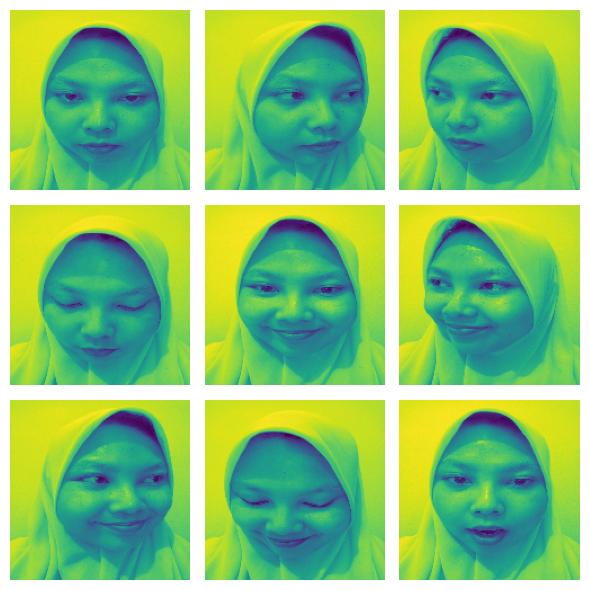

In [ ]:
# Load Dataset
x_train = load_dataset(DIRECTORY_train)
x_test = load_dataset(DIRECTORY_test)

print()  # biar tqdm selesai dulu
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

# Contoh nampilin 9 gambar dari data test
import matplotlib.pyplot as plt

# ambil 9 gambar pertama
sample_images = x_test[:9]

# buat figure 3x3
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# tampilkan gambar
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import keras
class MCDropout(keras.layers.Dropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

In [ ]:
from tensorflow.keras import models
from tensorflow.keras.layers import Activation, ZeroPadding2D, MaxPooling2D, Conv2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers, constraints

model = models.Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 1), padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2=0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2=0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(512, activation='relu', kernel_initializer="glorot_uniform", kernel_regularizer=regularizers.l2(l2=0.01)))

model.add(MCDropout(rate=0.5))

model.add(Dense(NUM_CLASSES, activation='softmax', kernel_initializer="glorot_uniform"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 78, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 39, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,334,543 (81.38 MB)

 Trainable params: 21,334,543 (81.38 MB)

 Non-trainable params: 0 (0.00 B)

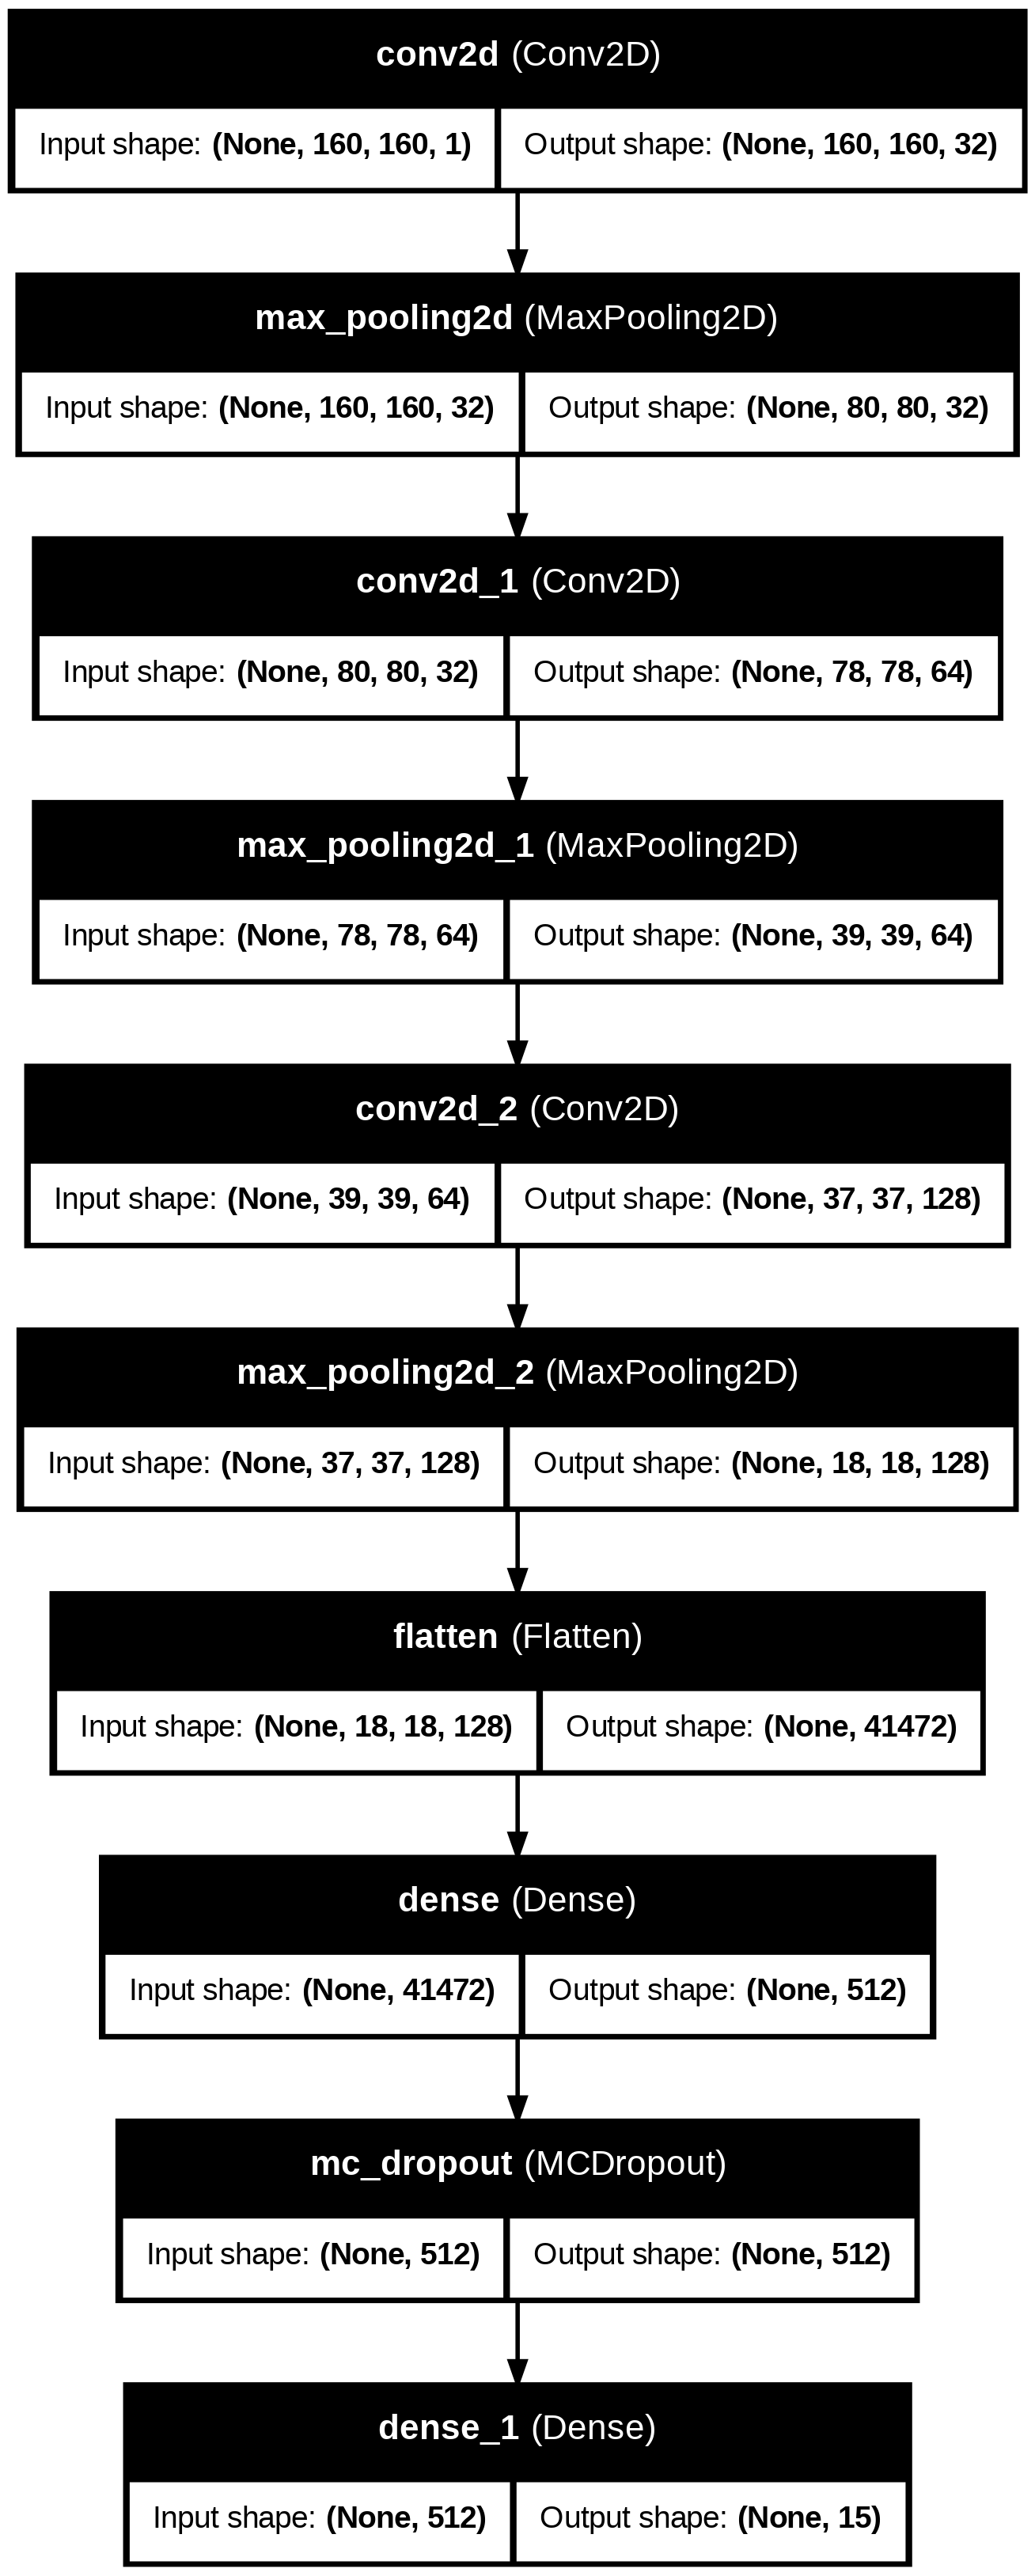

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model_architecture.png',   # opsional, bisa dihapus kalau gak mau nyimpan
    show_shapes=True,
    show_layer_names=True
)


buat cek kelas

In [ ]:
print("Jumlah kelas training:", training_generator.num_classes)
print("Jumlah kelas testing:", testing_generator.num_classes)


Jumlah kelas training: 53
Jumlah kelas testing: 53


In [ ]:
### epoch
# Import semua library yang dibutuhkan
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Tentukan lokasi folder dataset
DATA_TRAIN = "/content/drive/MyDrive/Dataset_Sistem_Presensi_Wajah_V2.0/Dataset_Sistem_Presensi_Wajah_V2.0 Data_Train"

# Ambil semua file gambar dengan ekstensi valid
valid_ext = ('.jpg', '.jpeg', '.png')
files = [f for f in os.listdir(DATA_TRAIN)
         if f.lower().endswith(valid_ext) and '_' in f]

print("Total file valid:", len(files))
print("Contoh:", files[:8])

# Siapkan list penampung data dan label
X = []
y = []

# Baca sebagian dulu biar gak berat (nanti bisa ubah 200 → len(files))
for file in tqdm(files[:1000], desc="Loading faces"):
    path = os.path.join(DATA_TRAIN, file)

    img = cv2.imread(path)
    if img is None:
        print(f"⚠ Gagal baca: {file}")
        continue

    img = cv2.resize(img, (160, 160))
    img = img / 255.0  # normalisasi

    # Ambil nama orang dari nama file → NIM_Nama_XX.jpg
    parts = file.split('_')
    if len(parts) >= 2:
        label = parts[1]
    else:
        label = "Unknown"

    X.append(img)
    y.append(label)

# Ubah ke numpy array
X = np.array(X)
y = np.array(y)

# Encode label ke angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Split jadi data latih & uji
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100,100,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Global Pooling (lebih akurat daripada Flatten)
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(len(le.classes_), activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Latih model
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

# Evaluasi hasil
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi: {acc*100:.2f}%")

# =====================================================
# SIMPAN MODEL DAN LABEL ENCODER
# =====================================================

save_path = "/content/drive/MyDrive/Model_FaceRecognition"
os.makedirs(save_path, exist_ok=True)

# Simpan model (.h5)
model_path = os.path.join(save_path, "face_cnn_model.h5")
model.save(model_path)
print("✔ Model disimpan di:", model_path)

# Simpan LabelEncoder (.pkl)
import pickle
le_path = os.path.join(save_path, "label_encoder.pkl")
with open(le_path, "wb") as f:
    pickle.dump(le, f)

print("✔ Label encoder disimpan di:", le_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total file valid: 1268
Contoh: ['5231811026_ULFAH NAFIAH_21.jpg', '5231811026_ULFAH NAFIAH_23.jpg', '5231811026_ULFAH NAFIAH_24.jpg', '5231811026_ULFAH NAFIAH_27.jpg', '5231811026_ULFAH NAFIAH_25.jpg', '5231811026_ULFAH NAFIAH_26.jpg', '5231811026_ULFAH NAFIAH_37.jpg', '5231811026_ULFAH NAFIAH_31.jpg']


Loading faces: 100%|██████████| 1000/1000 [01:17<00:00, 12.88it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.1277 - loss: 3.8734 - val_accuracy: 0.0200 - val_loss: 4.2507
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.5245 - loss: 1.9860 - val_accuracy: 0.0300 - val_loss: 5.0912
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.6412 - loss: 1.4904 - val_accuracy: 0.0200 - val_loss: 7.9085
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.7628 - loss: 0.9719 - val_accuracy: 0.0200 - val_loss: 10.7658
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8140 - loss: 0.7722 - val_accuracy: 0.0300 - val_loss: 12.0255
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.8661 - loss: 0.6350 - val_accuracy: 0.0300 - val_loss: 11.3272
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.8735 - loss: 0.5375 - val_accuracy: 0.0300 - val_loss: 11.9711
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.8814 - loss: 0.4676 - val_accuracy: 0.0200 -

Akurasi: 67.50%
✔ Model disimpan di: /content/drive/MyDrive/Model_FaceRecognition/face_cnn_model.h5
✔ Label encoder disimpan di: /content/drive/MyDrive/Model_FaceRecognition/label_encoder.pkl


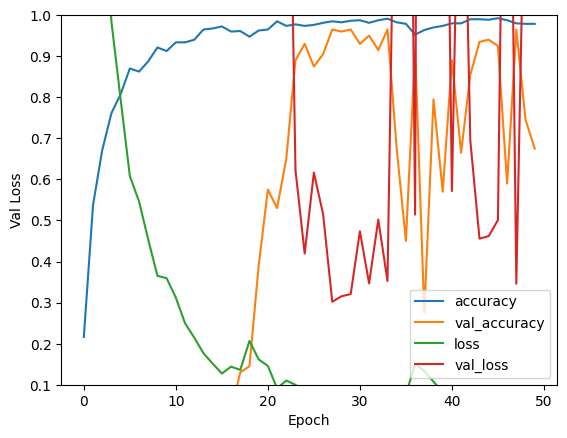

In [ ]:
plot_folder = "plot"
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.1, 1])
plt.legend(loc='lower right')

plot_folder = "plot"
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend(loc='lower right')

In [ ]:
loss, accuracy = model.evaluate(X_train, y_train)
print(f"Akurasi pada data train: {accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 763ms/step - accuracy: 0.7932 - loss: 0.6604
Akurasi pada data train: 80.50%


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi pada data test: {accuracy*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 554ms/step - accuracy: 0.6642 - loss: 1.4287
Akurasi pada data test: 67.50%


In [ ]:
!pip install mtcnn

# === IMPORT ===
from google.colab.patches import cv2_imshow
from IPython.display import Javascript, display, HTML
from google.colab.output import eval_js
from base64 import b64decode

import numpy as np
import cv2
import pickle
from tensorflow.keras.models import load_model
from mtcnn import MTCNN

# === LOAD MODEL ===
model = load_model("/content/drive/MyDrive/Model_FaceRecognition/face_cnn_model.h5")
with open("/content/drive/MyDrive/Model_FaceRecognition/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print("✔ Model & LabelEncoder loaded!")

detector = MTCNN()


# === JAVASCRIPT: PREVIEW + CAPTURE BUTTON ===
js = Javascript("""
async function startCamera(){
  const div = document.createElement('div');
  div.innerHTML = `
    <video id="previewCam" autoplay playsinline width="400" style="border:2px solid black; border-radius:10px;"></video><br>
    <button id="captureBtn" style="
      margin-top:10px;
      padding:12px 20px;
      background:#0275d8;
      border:none;
      border-radius:8px;
      color:white;
      font-size:16px;
      cursor:pointer;
    ">CAPTURE 📸</button>
  `;
  document.body.appendChild(div);

  const video = document.getElementById('previewCam');
  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;

  document.getElementById("captureBtn").onclick = async () => {
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0);

      google.colab.kernel.invokeFunction('capture.frame',
        [canvas.toDataURL('image/jpeg', 0.8)], {});

      // Stop kamera setelah capture
      stream.getVideoTracks()[0].stop();
  };
}

startCamera();
""")

display(js)


# === PYTHON CALLBACK UNTUK PROSES MODEL ===
def process_frame(data):
    img_bytes = b64decode(data.split(',')[1])
    img_np = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(img_np, cv2.IMREAD_COLOR)

    print("\n📸 Foto berhasil di-capture!\n")
    output = img.copy()

    # === DETEKSI MULTI-FACE ===
    faces = detector.detect_faces(img)

    if len(faces) == 0:
        print("❌ Tidak ada wajah terdeteksi.")
        cv2_imshow(img)
        return

    print(f"✔ {len(faces)} wajah terdeteksi!\n")

    for face in faces:
        x, y, w, h = face["box"]

        # Crop wajah
        crop = img[y:y+h, x:x+w]
        try:
            crop = cv2.resize(crop, (100, 100))
        except:
            continue

        crop = crop / 255.0
        crop = np.expand_dims(crop, axis=0)

        # Prediksi
        pred = model.predict(crop)[0]
        idx = np.argmax(pred)
        confidence = pred[idx] * 100
        name = le.classes_[idx]

        # Gambar bounding box
        cv2.rectangle(output, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(output, f"{name} ({confidence:.1f}%)",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0,255,0), 2)

    print("✔ Hasil prediksi:")
    cv2_imshow(output)


# Daftarkan callback ke Colab
from google.colab import output
output.register_callback('capture.frame', process_frame)

✔ Model & LabelEncoder loaded!


<IPython.core.display.Javascript object>

In [ ]:
from google.colab import output
from IPython.display import display, Javascript
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
import time
import os

# --- Konfigurasi Global ---
FILENAME = 'captured_face_result.jpg'
photo_ready = False
# Path ke model Haar Cascade
HAAR_CASCADE_PATH = cv2.data.haascades + 'haarcascade_frontalface_default.xml'

# --- 1. Fungsi Penangkapan Webcam (JavaScript) ---

def take_photo(filename=FILENAME):
    """Menampilkan widget kamera dan tombol 'Capture'."""
    js = Javascript('''
        async function takePhoto() {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          div.appendChild(video);
          document.body.appendChild(div);

          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          video.srcObject = stream;
          await video.play();
          video.width = 320;

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          const dataUrl = canvas.toDataURL('image/jpeg');
          return dataUrl;
        }

        takePhoto().then(dataUrl => {
          google.colab.kernel.invokeFunction('notebook.takePhoto', [dataUrl], {});
        });
    ''')
    display(js)

# --- 2. Callback untuk Menyimpan Foto (Python) ---

def takePhotoCallback(dataUrl):
    """Menerima data Base64 dari JS dan menyimpannya sebagai file."""
    global photo_ready
    try:
        image_data = b64decode(dataUrl.split(',')[1])
        with open(FILENAME, 'wb') as f:
            f.write(image_data)

        print(f"✅ Foto berhasil disimpan sebagai: {FILENAME}")
        photo_ready = True
    except Exception as err:
        print(f"❌ Error saat menyimpan foto: {str(err)}")

output.register_callback('notebook.takePhoto', takePhotoCallback)

# --- 3. Fungsi Deteksi Wajah (Akurasi Tinggi) ---

def detect_and_display_faces(image_path):
    """Memuat gambar, mendeteksi wajah dengan akurasi tinggi, dan menampilkan hasilnya."""

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Error: Tidak dapat memuat gambar dari {image_path}")
        return

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(HAAR_CASCADE_PATH)

    if face_cascade.empty():
        print("❌ Error: Gagal memuat Haar Cascade model.")
        return

    # **PARAMETER AKURASI TINGGI DI SINI:**
    # minNeighbors=7 membuat model lebih ketat, mengurangi False Positive.
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.05,
        minNeighbors=7,   # NILAI DITINGKATKAN untuk akurasi/mengurangi kesalahan deteksi
        minSize=(40, 40)
    )

    # Gambar kotak di sekitar wajah
    detection_count = len(faces)
    print(f"\n✨ Deteksi Wajah Selesai: Ditemukan {detection_count} wajah.")

    for (x, y, w, h) in faces:
        cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_bgr, 'Wajah', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)


    # Konversi BGR ke RGB dan tampilkan
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(img_rgb))

# ----------------------------------------------------
#               --- EKSEKUSI UTAMA ---
# ----------------------------------------------------

# 1. Reset flag
photo_ready = False

# 2. Instruksi dan Pemicu Penangkapan
print("------------------------------------------------------------------")
print("1. Mohon izinkan akses kamera di browser Anda jika diminta.")
print("2. Setelah kamera muncul, klik tombol 'Capture' untuk mengambil foto.")
print("------------------------------------------------------------------")
take_photo(FILENAME)

# 3. Tunggu hingga foto berhasil disimpan
while not photo_ready:
    time.sleep(0.5)

# 4. Lakukan Deteksi Wajah
if os.path.exists(FILENAME):
    detect_and_display_faces(FILENAME)
else:
    print(f"❌ Error: File {FILENAME} tidak ditemukan untuk diproses.")

AttributeError: module 'cv2.data' has no attribute 'haascades'

In [ ]:
import cv2
import numpy as np
import time
from mtcnn import MTCNN
from IPython.display import clear_output
import matplotlib.pyplot as plt

detector = MTCNN()

while True:
    data = eval_js("getFrame()")
    bytes_data = b64decode(data.split(',')[1])
    frame = cv2.imdecode(np.frombuffer(bytes_data, np.uint8), 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb)

    for face in faces:
        x, y, w, h = face["box"]
        x, y = max(0, x), max(0, y)

        crop = rgb[y:y+h, x:x+w]
        if crop.size == 0:  # skip kalau crop kosong
            continue

        crop = cv2.resize(crop, (100,100))
        crop = crop.astype("float32")/255
        crop = np.expand_dims(crop, axis=0)

        pred = model.predict(crop)[0]
        idx = np.argmax(pred)
        name = le.classes_[idx]
        conf = pred[idx]

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"{name} {conf:.2f}", (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,0),2)

    # tampilkan frame di Colab
    clear_output(wait=True)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    time.sleep(0.03)  # ~30 fps

MessageError: ReferenceError: Can't find variable: getFrame

In [ ]:
# ======================================================
#   REALTIME FACE RECOGNITION WITH CNN + MTCNN + WEBCAM
# ======================================================

from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from mtcnn import MTCNN

# Pakai model CNN & LabelEncoder yang kamu sudah train di atas
detector = MTCNN()

model = model
le = le

# =================================
#  JS: WEBCAM + CANVAS + CAPTURE
# =================================
js = Javascript('''
async function setupCam() {
  const video = document.createElement('video');
  video.style.display = 'none';
  document.body.append(video);

  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;
  await video.play();

  const canvas = document.createElement('canvas');
  document.body.append(canvas);
  const ctx = canvas.getContext('2d');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;

  window.getFrame = async function() {
    ctx.drawImage(video, 0, 0);
    return canvas.toDataURL('image/jpeg', 0.8);
  };

  return "ready";
}
''')

display(js)
eval_js("setupCam()")
print("Webcam siap...")

# ==============================
#  REALTIME LOOP
# ==============================

while True:
    data = eval_js("getFrame()")
    bytes_data = b64decode(data.split(',')[1])
    frame = cv2.imdecode(np.frombuffer(bytes_data, np.uint8), 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb)

    for face in faces:
        x, y, w, h = face["box"]
        x = max(0,x); y = max(0,y)

        crop = rgb[y:y+h, x:x+w]
        crop = cv2.resize(crop, (100,100))
        crop = crop.astype("float32")/255
        crop = np.expand_dims(crop, axis=0)

        pred = model.predict(crop)[0]
        idx = np.argmax(pred)
        name = le.classes_[idx]
        conf = pred[idx]

        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(frame,f"{name} {conf:.2f}", (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,0.8,(0,255,0),2)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    plt.close()

    time.sleep(0.0000002)